# **Gold Price Time Series Analyze**
#### **Daily gold prices** from January 1, 2014 to January 2, 2026

### Import Necessary Library

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from datetime import timedelta
from sklearn.metrics import confusion_matrix,mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import models, layers

### Read Data, Explore data

In [11]:
data=pd.read_csv('Gold Price.csv')

In [12]:
data.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,1/1/2014,29542,29435,29598,29340,2930,0.25
1,1/2/2014,29975,29678,30050,29678,3140,1.47
2,1/3/2014,29727,30031,30125,29539,3050,-0.83
3,1/4/2014,29279,29279,29279,29279,0,-1.51
4,1/6/2014,29119,29300,29395,29051,24380,-0.55


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   str    
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), str(1)
memory usage: 169.9 KB


In [14]:
data.describe()

,Price,Open,High,Low,Volume,Chg%
count,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000
mean,46263.721972,46250.184278,46515.665271,45997.234214,14855.159472,0.052957
std,22230.385519,22191.261855,22364.944669,22053.596236,14197.123722,0.854364
min,24545.000000,24583.000000,24635.000000,24470.000000,0.000000,-5.980000
25%,29358.750000,29331.500000,29462.750000,29214.000000,6780.000000,-0.370000
50%,38832.500000,38902.500000,39083.000000,38626.500000,11520.000000,0.060000
75%,54970.250000,54900.000000,55211.250000,54730.500000,18602.500000,0.480000
max,137789.000000,137628.000000,138300.000000,136300.000000,149474.000000,5.300000


In [15]:
# Convert the 'Date' column to datetime format
data['Date']=pd.to_datetime(data['Date'])

In [16]:
data['Month']=data['Date'].dt.month_name()
data['Year']=data['Date'].dt.year

In [17]:
#set the index by date
data=data.set_index('Date')

In [18]:
data.head()

,Price,Open,High,Low,Volume,Chg%,Month,Year
Date,,,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25,January,2014
2014-01-02,29975,29678,30050,29678,3140,1.47,January,2014
2014-01-03,29727,30031,30125,29539,3050,-0.83,January,2014
2014-01-04,29279,29279,29279,29279,0,-1.51,January,2014
2014-01-06,29119,29300,29395,29051,24380,-0.55,January,2014


In [19]:
data['Year'].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025, 2026], dtype=int32)

In [20]:
data['Month'].unique()

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

### EDA

In [21]:
def plot_feature(col,color):
   plt.plot(data[col],color)
   plt.title(f'Trend of {col}')
   plt.ylabel(f'{col}')

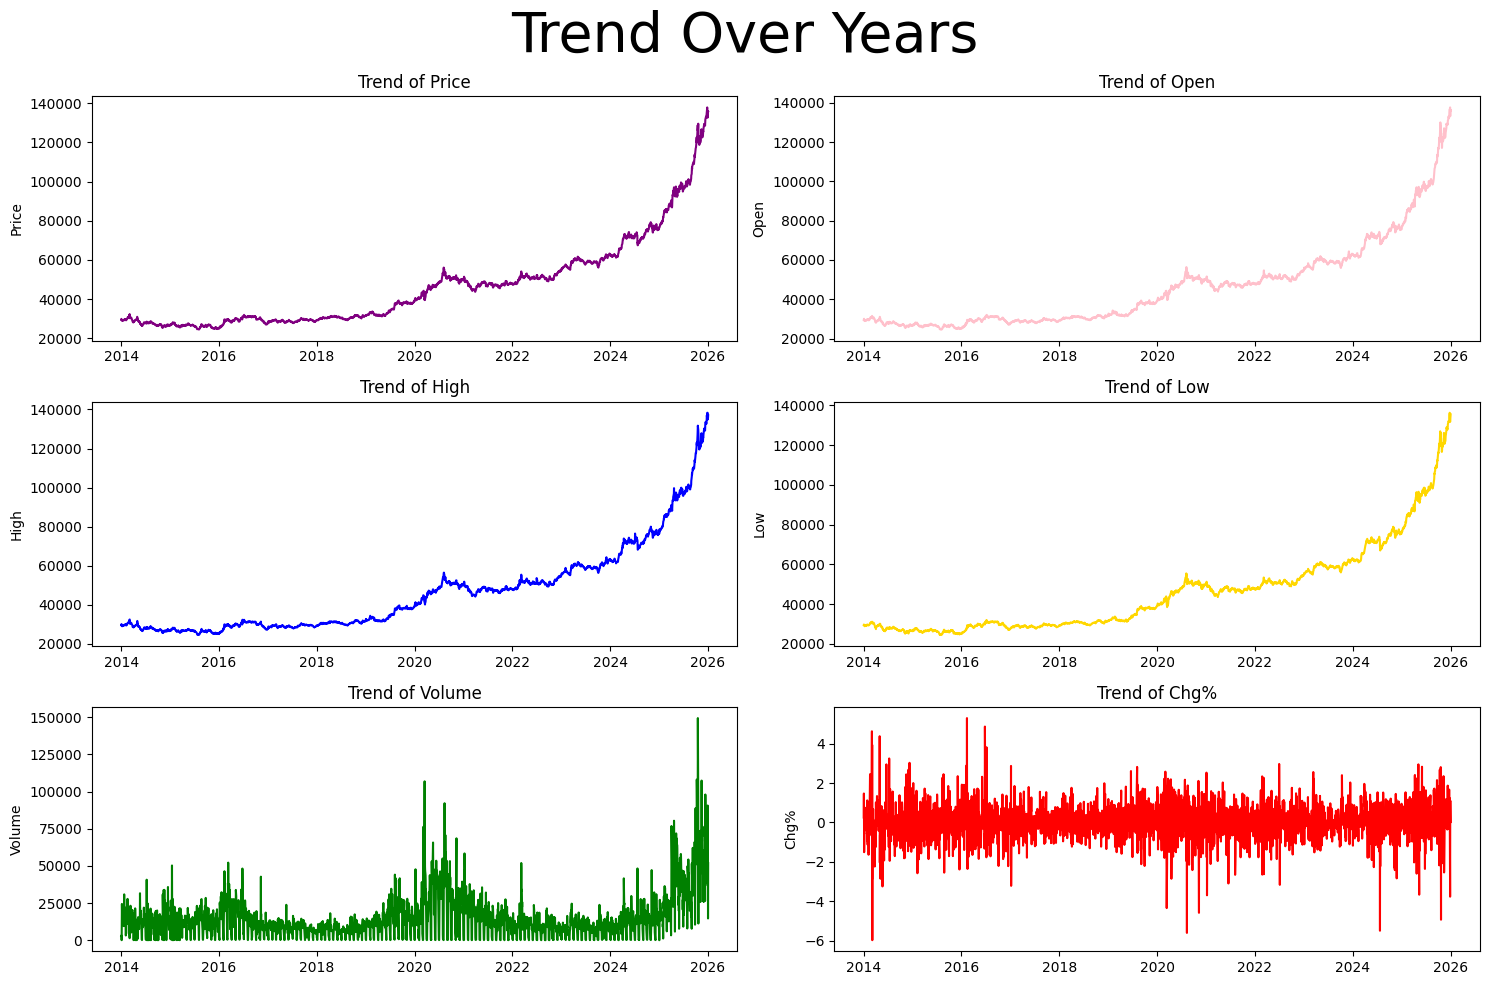

In [22]:
plt.figure(figsize=(15,10))
colors=['purple','pink','blue','gold','green','red']
plt.suptitle('Trend Over Years',fontsize=40)
for i,col in enumerate(data.columns[:-2]):
    plt.subplot(3,2,i+1)
    plot_feature(col,colors[i])
plt.tight_layout()
plt.show()

In [23]:
#total price over months
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_grouped=data.groupby('Month').sum()
month_grouped=month_grouped.sort_values(by='Price')
month_grouped=month_grouped.reindex(months)
month_grouped

,Price,Open,High,Low,Volume,Chg%,Year
Month,,,,,,,
January,11349070,11341792,11398333,11295207,3446633,38.64,533149
February,10652553,10654794,10713876,10591438,3109291,11.06,496795
March,11466112,11461936,11539432,11386938,4217844,6.28,531122
April,11180768,11170459,11246753,11103430,3603605,38.91,496785
May,12175460,12174600,12244035,12105720,4326861,-5.61,537193
June,11751735,11754937,11814017,11690870,3649135,7.55,519005
July,12445472,12447146,12511454,12382435,4054505,10.76,545243
August,11953597,11946187,12014771,11883535,3812367,20.87,519006
September,12379776,12376573,12440236,12313638,3999501,0.42,525057


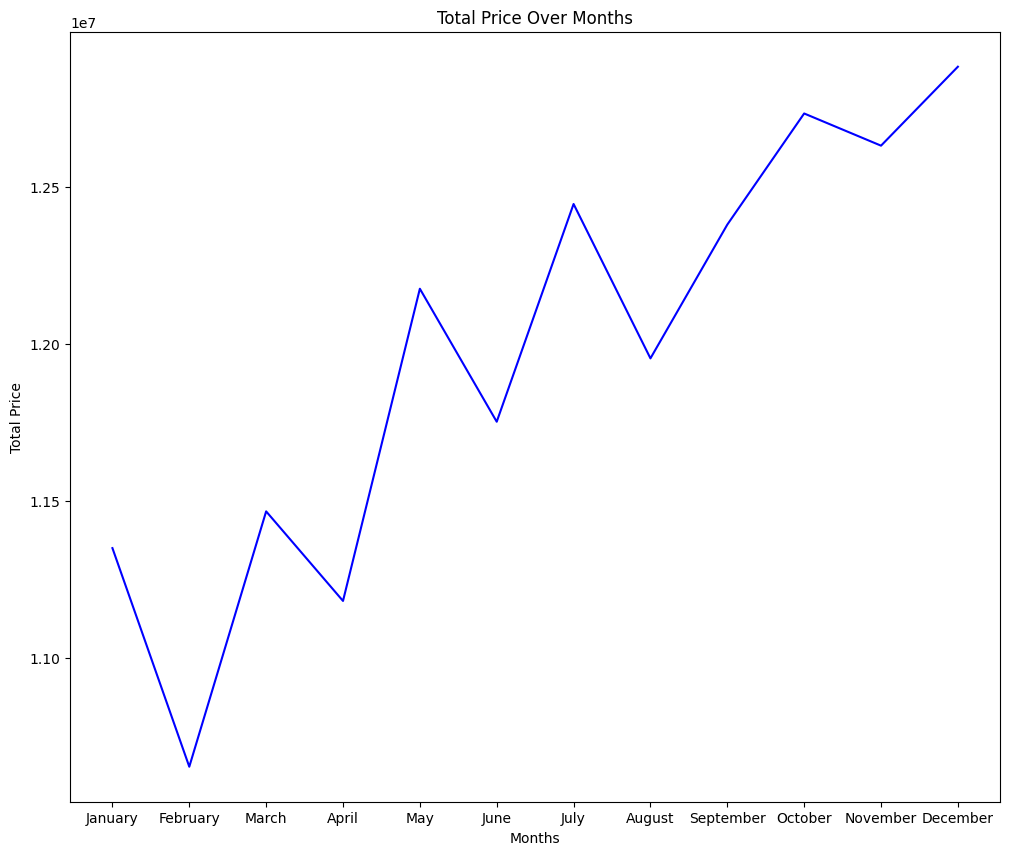

In [24]:
plt.figure(figsize=(12,10))
plt.title('Total Price Over Months')
plt.xlabel('Months')
plt.ylabel('Total Price')
plt.plot(month_grouped.index,month_grouped['Price'],colors[2])
plt.show()

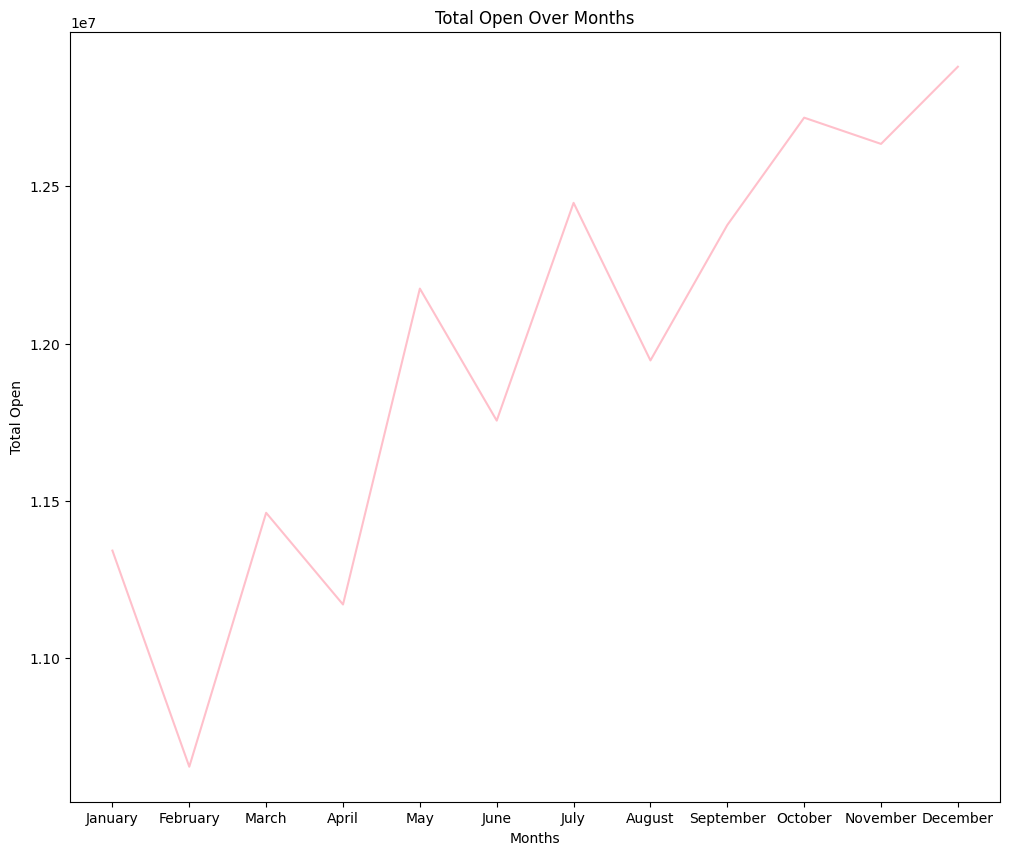

In [25]:
plt.figure(figsize=(12,10))
plt.title('Total Open Over Months')
plt.xlabel('Months')
plt.ylabel('Total Open')
plt.plot(month_grouped.index,month_grouped['Open'],colors[1])
plt.show()


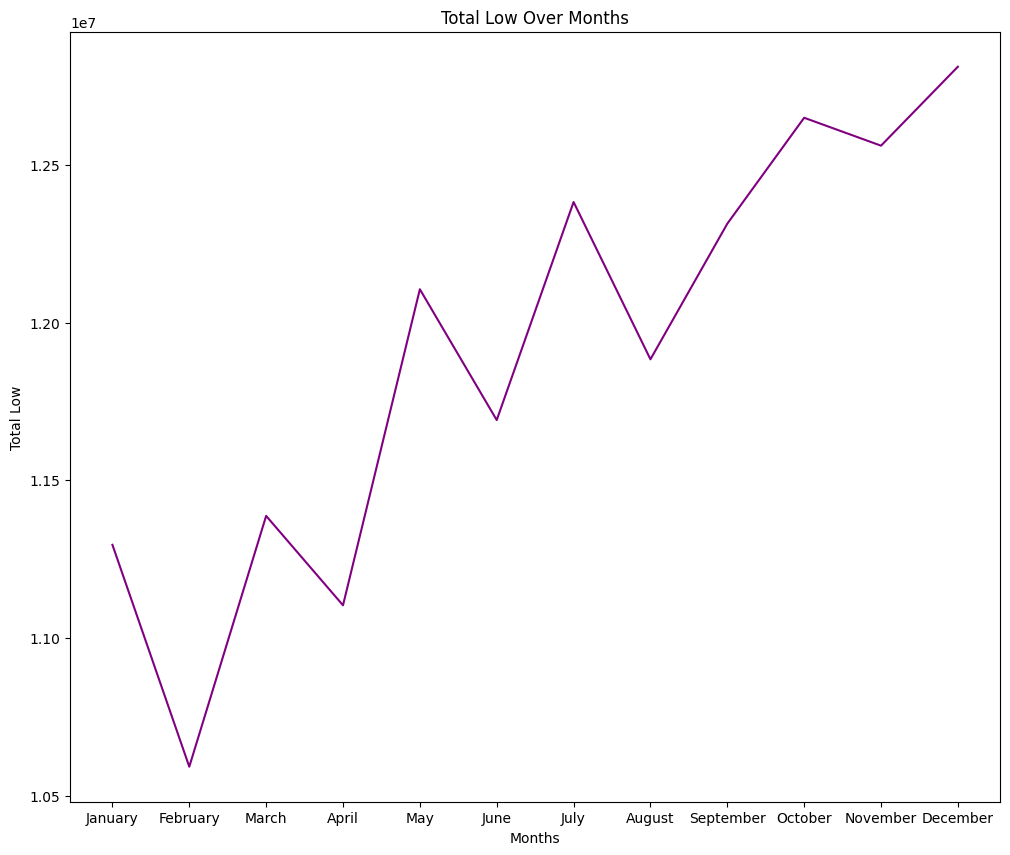

In [26]:
plt.figure(figsize=(12,10))
plt.title('Total Low Over Months')
plt.xlabel('Months')
plt.ylabel('Total Low')
plt.plot(month_grouped.index,month_grouped['Low'],colors[0])
plt.show()

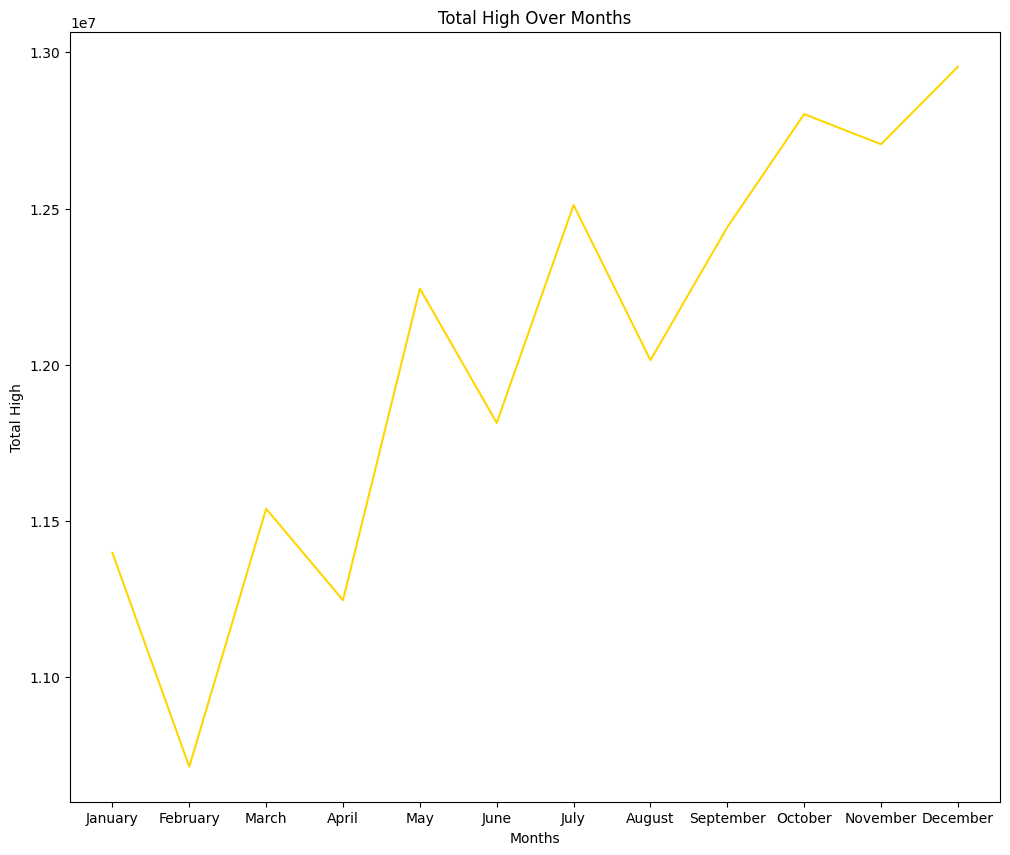

In [27]:
plt.figure(figsize=(12,10))
plt.title('Total High Over Months')
plt.plot(month_grouped.index,month_grouped['High'],colors[3])
plt.xlabel('Months')
plt.ylabel('Total High')
plt.show()


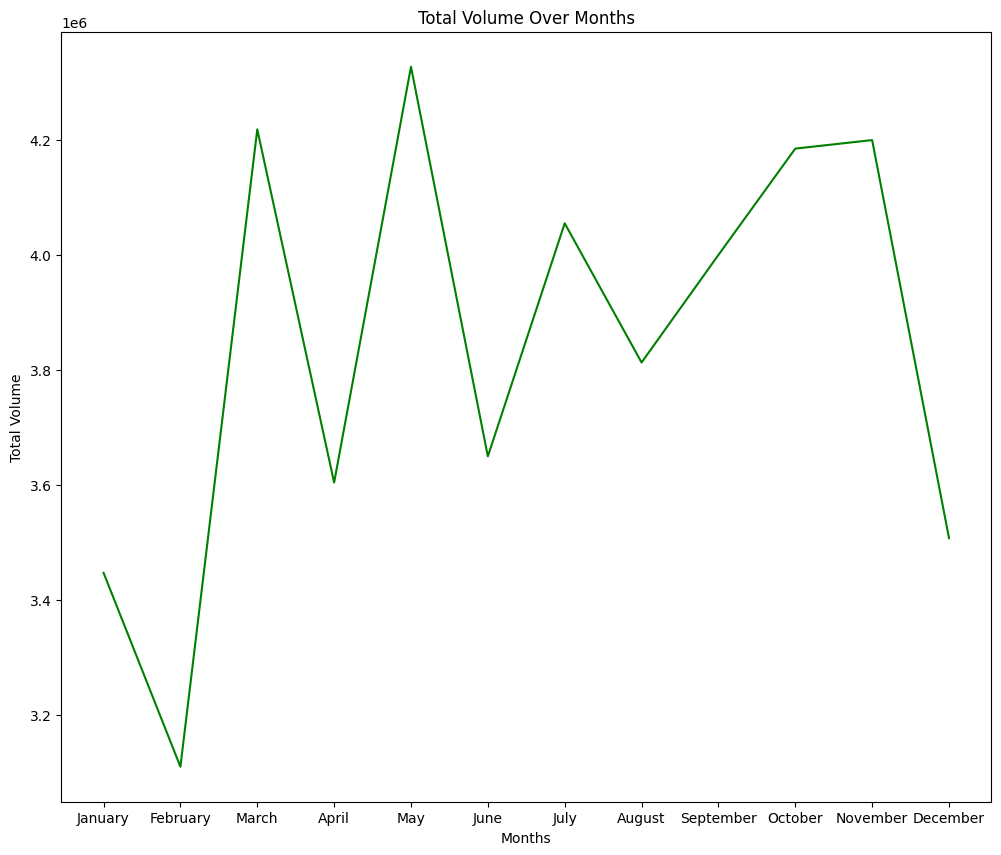

In [28]:
plt.figure(figsize=(12,10))
plt.title('Total Volume Over Months')
plt.plot(month_grouped.index,month_grouped['Volume'],colors[4])
plt.xlabel('Months')
plt.ylabel('Total Volume')
plt.show()

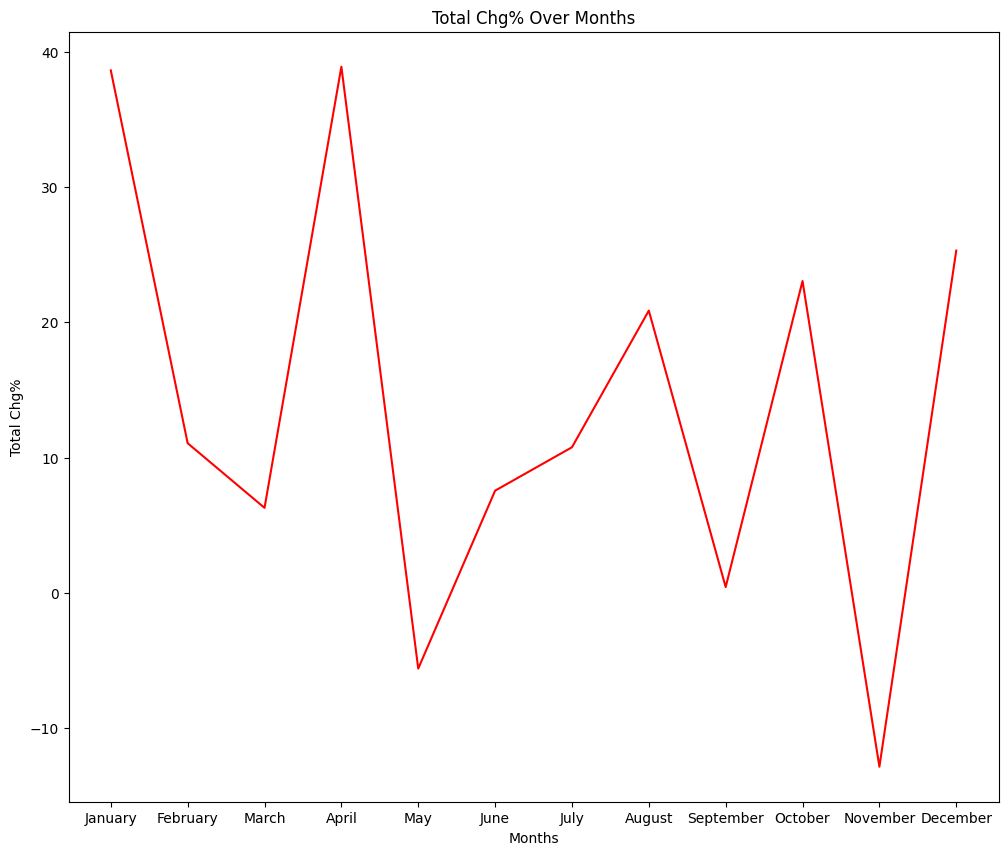

In [29]:
plt.figure(figsize=(12,10))
plt.title('Total Chg% Over Months')
plt.plot(month_grouped.index,month_grouped['Chg%'],colors[5])
plt.xlabel('Months')
plt.ylabel('Total Chg%')
plt.show()


In [30]:
years=data['Year'].unique()
grouped_year=data.groupby('Year',)[data.columns[:-2]].mean()
grouped_year=grouped_year.sort_values(by='Price')
grouped_year=grouped_year.reindex(years)
grouped_year


,Price,Open,High,Low,Volume,Chg%
Year,,,,,,
2014,28101.361940,28091.723881,28273.578358,27927.854478,12407.313433,-0.032724
2015,26304.965649,26321.713740,26461.156489,26167.580153,12675.835878,-0.021069
2016,29427.718147,29433.193050,29611.220077,29255.996139,14576.096525,0.045097
2017,28949.235294,28941.313725,29060.498039,28827.043137,7799.596078,0.025255
2018,30635.257812,30631.300781,30757.191406,30514.167969,7081.398438,0.028945
2019,34887.945525,34888.221790,35070.163424,34707.276265,13946.809339,0.085992
2020,47267.914729,47247.779070,47604.972868,46854.120155,26857.860465,0.103488
2021,47344.729730,47377.814672,47603.216216,47115.200772,14459.922780,-0.013475
2022,50994.568093,51001.322957,51267.871595,50745.276265,9279.525292,0.054786


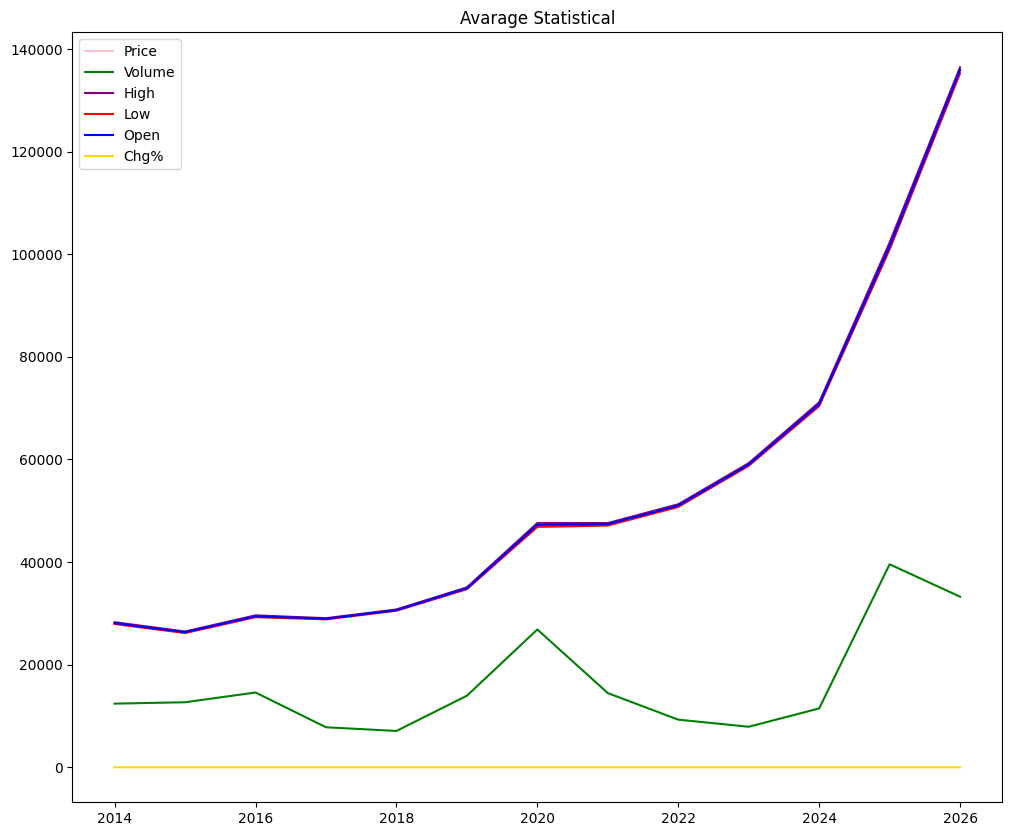

In [31]:
plt.figure(figsize=(12,10))
plt.plot(grouped_year['Price'],colors[1])
plt.plot(grouped_year['Volume'],colors[4])
plt.plot(grouped_year['High'],colors[0])
plt.plot(grouped_year['Low'],colors[5])
plt.plot(grouped_year['Open'],colors[2])
plt.plot(grouped_year['Chg%'],colors[3])
plt.legend(['Price','Volume','High','Low','Open','Chg%'])
plt.title(f'Avarage Statistical')
plt.show()